In [1]:
import os 
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import scgen
import seaborn as sns
from scipy import stats
import matplotlib
from scgen.file_utils import ensure_dir
matplotlib.rc('ytick', labelsize=18)
matplotlib.rc('xtick', labelsize=18)
sc.set_figure_params(dpi_save=300)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-16 01:09:11.666711: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-16 01:09:11.772631: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
path_to_save = "../results/Figures/Supplemental Figure 2/"
ensure_dir(path_to_save)
sc.settings.figdir = path_to_save

In [3]:
pbmc = scgen.load_file("../data/train_pbmc.h5ad")
pbmc

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 16893 × 6998
    obs: 'condition', 'n_counts', 'n_genes', 'mt_frac', 'cell_type'
    var: 'gene_symbol', 'n_cells'
    uns: 'cell_type_colors', 'condition_colors', 'neighbors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'distances', 'connectivities'

In [4]:
pbmc.obs.groupby(['cell_type', 'condition']).size()

/tmp/ipykernel_75327/191267336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pbmc.obs.groupby(['cell_type', 'condition']).size()


cell_type    condition 
CD4T         control       2437
             stimulated    3127
CD14+Mono    control       1946
             stimulated     615
B            control        818
             stimulated     993
CD8T         control        574
             stimulated     541
NK           control        517
             stimulated     646
FCGR3A+Mono  control       1100
             stimulated    2501
Dendritic    control        615
             stimulated     463
dtype: int64

In [5]:
scgen_recon = scgen.load_file("../data/reconstructed/scGen/pbmc.h5ad")
ctrl = scgen_recon[scgen_recon.obs["condition"] == "CD4T_ctrl"]
real_stim = scgen_recon[scgen_recon.obs["condition"] == "CD4T_real_stim"]
scgen_recon = scgen_recon[scgen_recon.obs["condition"].isin(["CD4T_real_stim", "CD4T_pred_stim", "CD4T_ctrl"])]
scgen_recon

View of AnnData object with n_obs × n_vars = 8001 × 6998
    obs: 'condition', 'cell_type', 'batch'

In [6]:
scgen_recon.obs.groupby(['cell_type', 'condition']).size()

/tmp/ipykernel_75327/1667140818.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scgen_recon.obs.groupby(['cell_type', 'condition']).size()


cell_type  condition     
CD4T       CD4T_ctrl         2437
           CD4T_pred_stim    2437
           CD4T_real_stim    3127
dtype: int64

In [7]:
cvae = scgen.load_file("../data/reconstructed/CVAE/CVAE_CD4T.h5ad")
cvae.obs.groupby(['cell_type', 'condition']).size()

/tmp/ipykernel_75327/750892210.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cvae.obs.groupby(['cell_type', 'condition']).size()


cell_type  condition 
CD4T       control       2437
           pred             0
           stimulated    3127
dtype: int64

In [8]:
stgan = scgen.load_file("../data/reconstructed/CGAN/cgan_cd4t.h5ad")
stgan.obs.groupby(['condition']).size()

/tmp/ipykernel_75327/3618573635.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stgan.obs.groupby(['condition']).size()


condition
ctrl         2437
pred_stim    2437
real_stim    3127
dtype: int64

In [9]:
vecArith = scgen.load_file("../data/reconstructed/VecArithm/VecArithm_CD4T.h5ad")
vecArith.obs.groupby(['condition']).size()

/tmp/ipykernel_75327/3437586436.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vecArith.obs.groupby(['condition']).size()


condition
ctrl         2437
pred_stim    2437
real_stim    3127
dtype: int64

In [10]:
pca = scgen.load_file("../data/reconstructed/PCAVecArithm/PCA_CD4T.h5ad")
pca.obs.groupby(['condition']).size()

/tmp/ipykernel_75327/758581352.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pca.obs.groupby(['condition']).size()


condition
ctrl         2437
pred_stim    2437
real_stim    3127
dtype: int64

In [11]:
cd4t = pbmc[pbmc.obs["cell_type"] == "CD4T"]
sc.tl.rank_genes_groups(cd4t, groupby="condition", n_genes=100, method="wilcoxon")
diff_genes = cd4t.uns["rank_genes_groups"]["names"]["stimulated"]

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


### Suppl. Figure 2.a

In [12]:
def make_plots(adata, conditions, model_name, figure, x_coeff=0.3, y_coeff=0.1):
    if model_name == "RealCD4T":
        mean_labels = {"x": "ctrl mean", "y": "stim mean"}
        var_labels = {"x": "ctrl var", "y": "stim var"}
    else:
        mean_labels = {"x": "pred mean", "y": "stim mean"}
        var_labels = {"x": "pred var", "y": "stim var"}
    print(adata.obs.groupby(['condition']).size())
    scgen.plotting.reg_mean_plot(adata, 
                                 condition_key="condition",
                                 axis_keys={"x": conditions["pred_stim"], "y": conditions["real_stim"]},
                                 gene_list=diff_genes[:5],
                                 top_100_genes=diff_genes,
                                 path_to_save=os.path.join(path_to_save, f"SupplFig2{figure}_{model_name}_reg_mean.pdf"),
                                 legend=False,
                                 title="",
                                 labels=mean_labels,
                                 fontsize=26,
                                 textsize=18,
                                 x_coeff=x_coeff,
                                 y_coeff=y_coeff,
                                 show=True,
                                 range=[0, 5, 1])
    
    scgen.plotting.reg_var_plot(adata, 
                                condition_key="condition",
                                axis_keys={"x": conditions["pred_stim"], "y": conditions["real_stim"]},
                                gene_list=diff_genes[:5],
                                top_100_genes=diff_genes,
                                path_to_save=os.path.join(path_to_save, f"SupplFig2{figure}_{model_name}_reg_var.pdf"),
                                legend=False,
                                labels=var_labels,
                                title="",
                                fontsize=26,
                                textsize=18,
                                x_coeff=x_coeff,
                                y_coeff=y_coeff,
                                show=True)
    if model_name == "scGen":
        adata = adata[adata.obs["condition"].isin(["CD4T_ctrl", "CD4T_pred_stim", "CD4T_real_stim"])]
        adata.obs["condition"].replace("CD4T_ctrl", "ctrl", inplace=True)
        adata.obs["condition"].replace("CD4T_real_stim", "real_stim", inplace=True)
        adata.obs["condition"].replace("CD4T_pred_stim", "pred_stim", inplace=True)
    sc.pp.neighbors(adata, n_neighbors=20)
    sc.tl.umap(adata, min_dist=1.1)
    import matplotlib.style
    plt.style.use('default')
    if model_name == "scGen":
        sc.pl.umap(adata, color=["condition"],
                   legend_loc=False,
                   frameon=False,
                   title="",
                   palette=matplotlib.rcParams["axes.prop_cycle"],
                   save=f"_latent_conditions.png",
                   show=True)
    else:
        if model_name == "RealCD4T":
            sc.pl.umap(adata, color=["condition"],
                   legend_loc=False,
                   frameon=False,
                   title="",
                   palette=['#1f77b4', '#2ca02c'],
                   save=f"_latent_conditions.png",
                   show=True)
        else:
            
            sc.pl.umap(adata, color=["condition"],
                       legend_loc=False,
                       frameon=False,
                       title="",
                       palette=matplotlib.rcParams["axes.prop_cycle"],
                       save=f"_latent_conditions.png",
                       show=True)
    
    os.rename(src=os.path.join(path_to_save, "umap_latent_conditions.png"), 
              dst=os.path.join(path_to_save, f"SupplFig2{figure}_{model_name}_umap.png"))

/tmp/ipykernel_75327/4010587713.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby(['condition']).size())


condition
CD4T_ctrl         2437
CD4T_pred_stim    2437
CD4T_real_stim    3127
dtype: int64
0.9618238392320636
0.9325653893377311


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


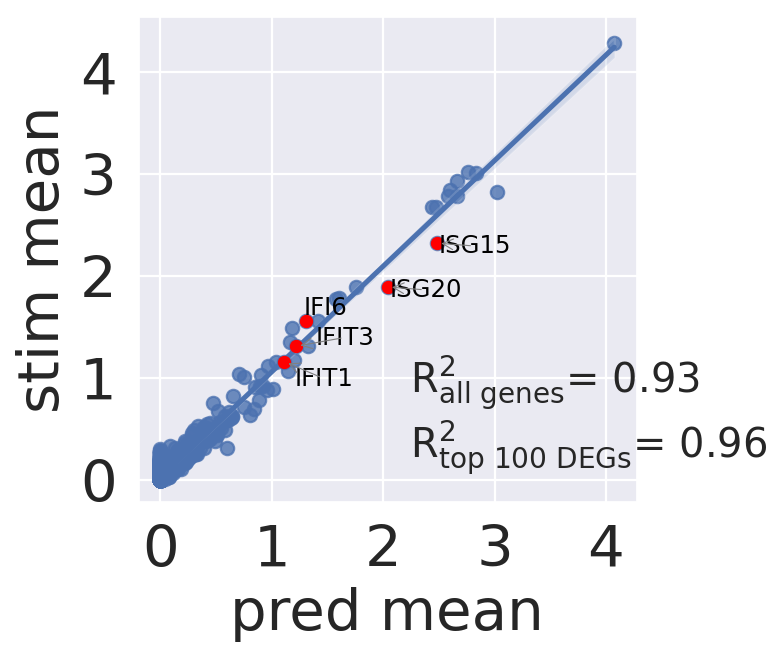

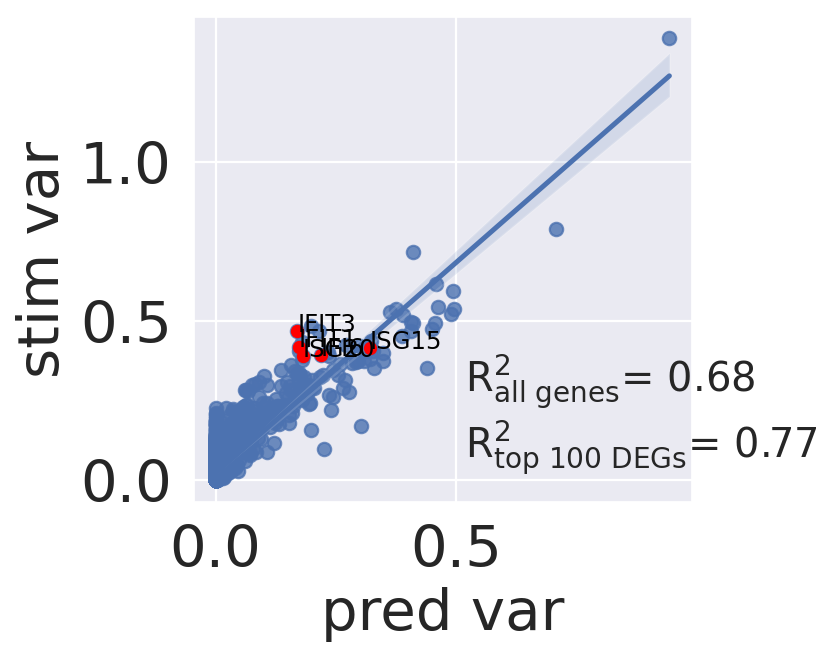

/tmp/ipykernel_75327/4010587713.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adata.obs["condition"].replace("CD4T_ctrl", "ctrl", inplace=True)
/tmp/ipykernel_75327/4010587713.py:41: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["condition"].replace("CD4T_ctrl", "ctrl", inplace=True)
/tmp/ipykernel_

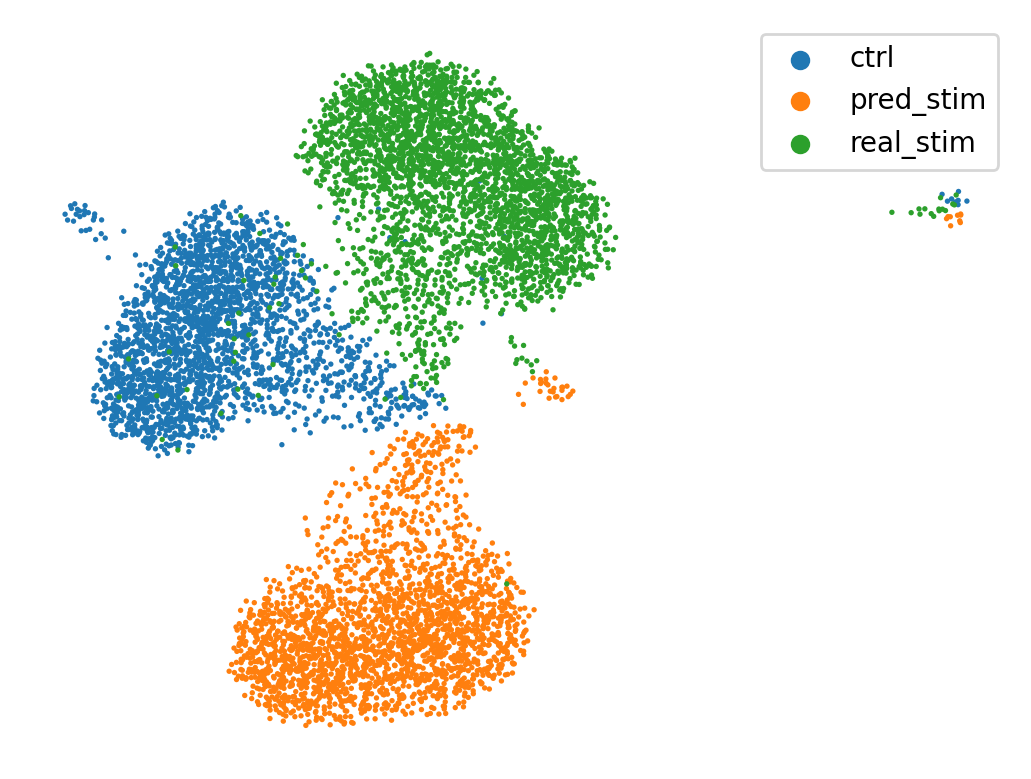

In [13]:
conditions = {"real_stim": "CD4T_real_stim", "pred_stim": "CD4T_pred_stim"}
make_plots(scgen_recon, conditions, "scGen", "a", 0.45, 0.8)

/tmp/ipykernel_75327/4010587713.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata.obs.groupby(['condition']).size())
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


condition
control       2437
pred          2437
stimulated    3127
dtype: int64
nan
nan


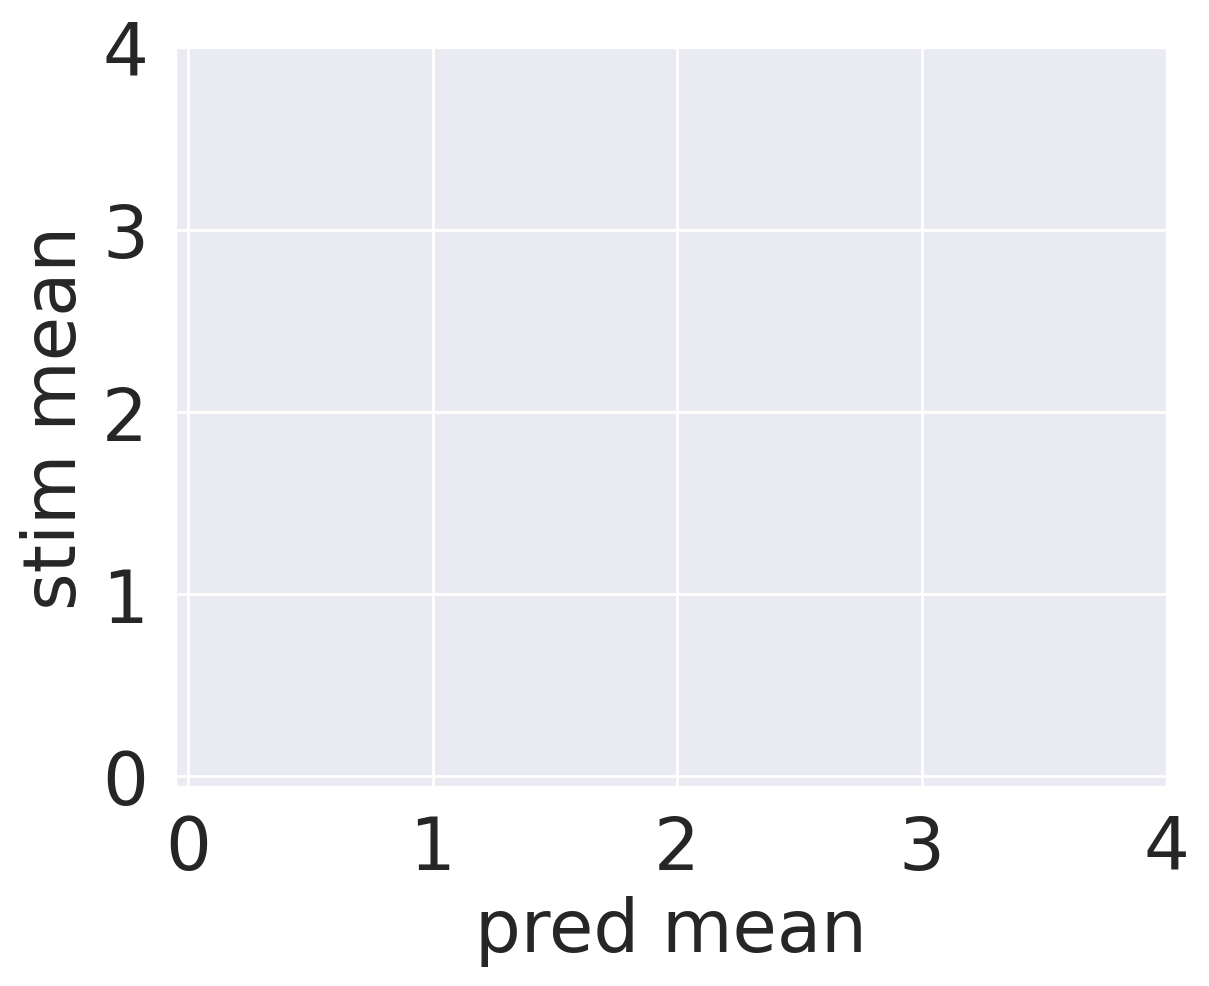

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3785: RuntimeWarning: Degrees of freedom <= 0 for slice
  return var(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/numpy/core/_methods.py:195: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


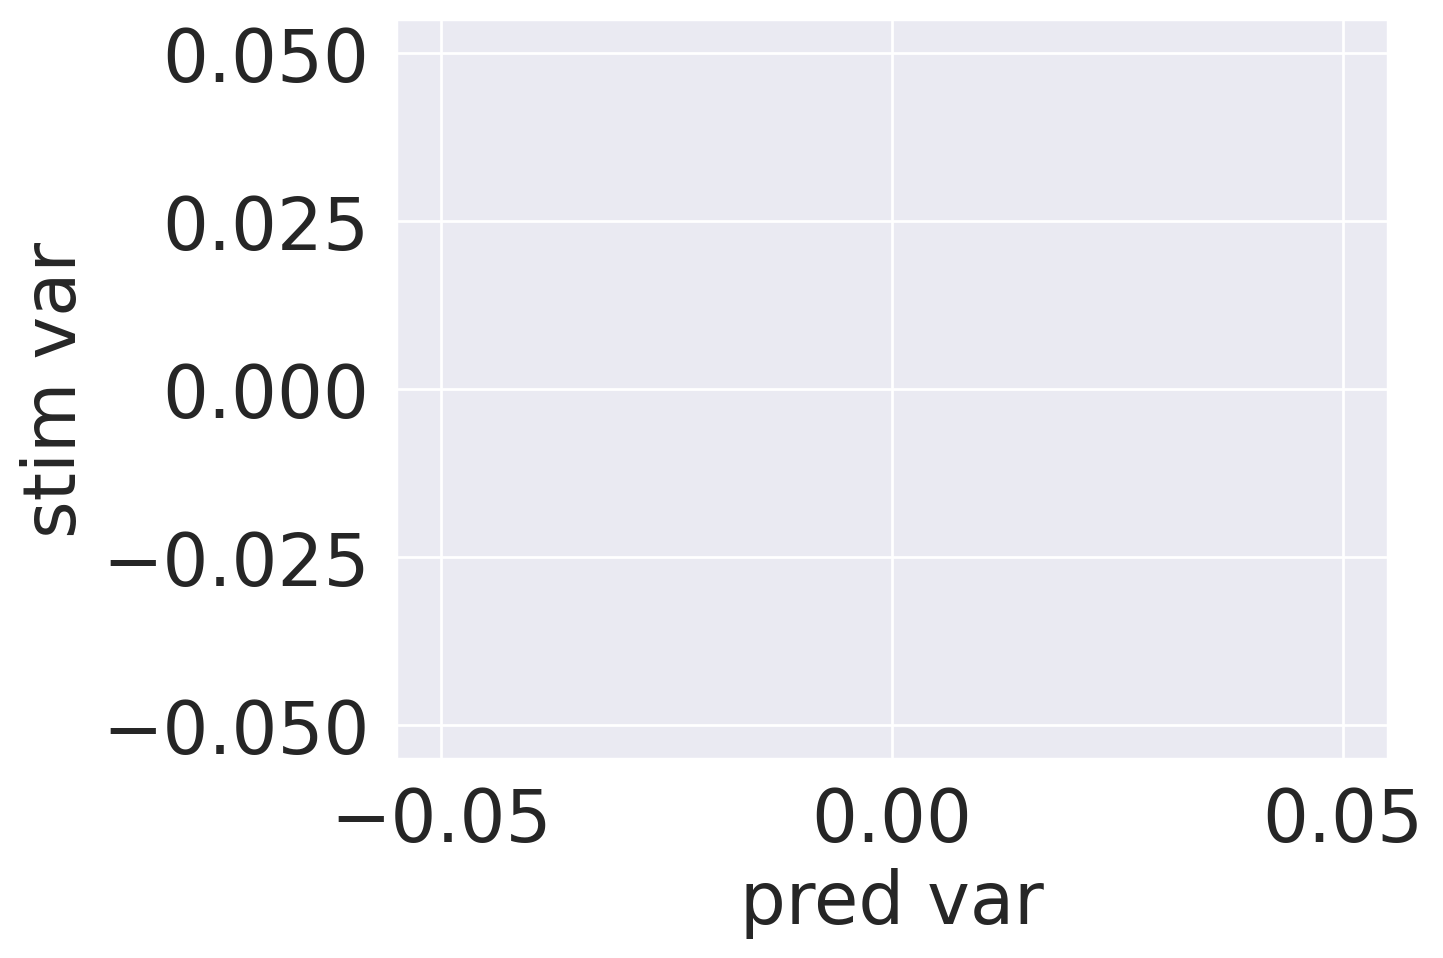

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 6998 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


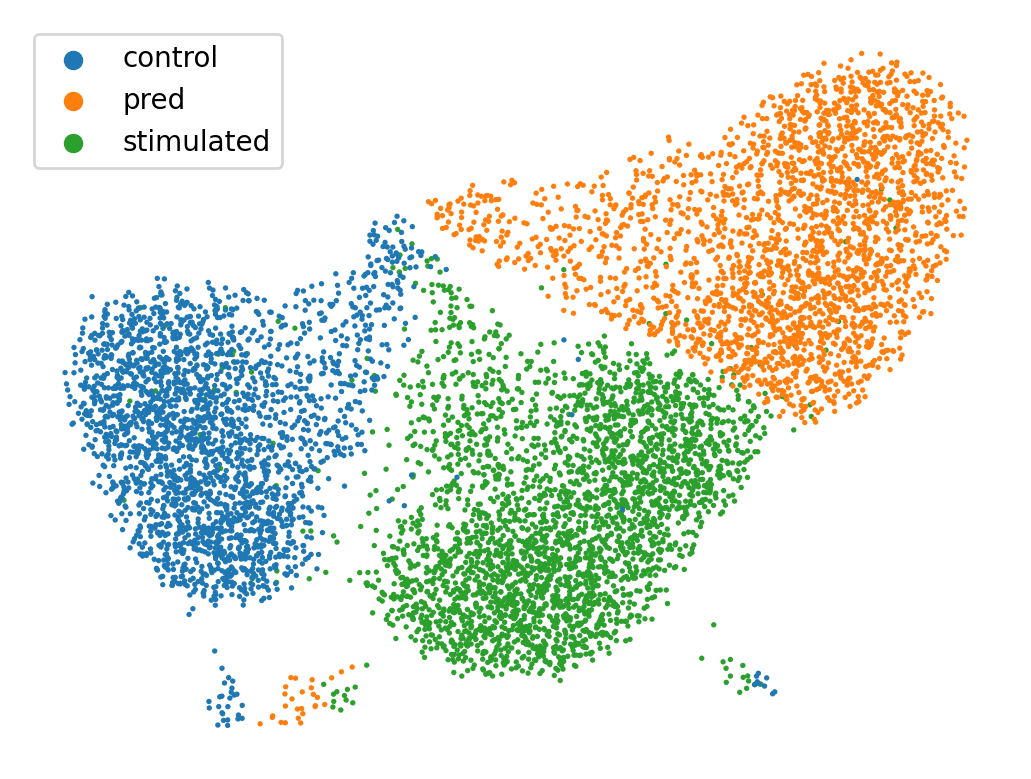

In [ ]:
conditions = {"real_stim": "CD4T_real_stim", "pred_stim": "CD4T_pred_stim"}
make_plots(cvae, conditions, "CVAE", "b", 0.45, 0.8)

In [ ]:
conditions = {"real_stim": "real_stim", "pred_stim": "pred_stim"}
make_plots(stgan, conditions, "Style Transfer GAN", "c", 0.45)

In [ ]:
conditions = {"real_stim": "real_stim", "pred_stim": "pred_stim"}
make_plots(vecArith, conditions, "Vec. Arith.", "d", 0.45, 0.8)

In [ ]:
conditions = {"real_stim": "real_stim", "pred_stim": "pred_stim"}
make_plots(pca, conditions, "PCA + Vec. Arith.", "e", 0.5, 0.8)

In [ ]:
conditions = {"real_stim": "stimulated", "pred_stim": "control"}
pbmc_cd4t = pbmc[pbmc.obs["cell_type"] == "CD4T"]
make_plots(pbmc_cd4t, conditions, "RealCD4T", "f", 0.45, 0.8) 